# Прогнозирование оттока игроков

Цель ноутбука — закрыть исследовательские пункты по объему обучающей выборки, доле целевой переменной, схеме валидации, признаковому пространству, сравнению параметрических семейств моделей и отбору признаков.

Источник данных: подготовленная рабочая выборка `data/combined_users_features.csv`. Ноутбук фиксирует методику анализа и качество моделей на текущей версии датасета.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

from config.settings import FEATURES, RANDOM_STATE, RAW_DATA_PATH, TARGET_COLUMN, TRAIN_TEST_SPLIT
from data_pipeline.dataset import build_feature_matrix, load_dataset
from training.trainer import train_and_save_model

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Загрузка данных и объем выборки
На первом шаге фиксируем размер датасета, состав таргета и рабочее признаковое пространство.

In [2]:
df = load_dataset()
X_shared, y = build_feature_matrix(df)
y = y.astype(int)

BASELINE_FEATURES = [
    "events_per_session_avg",
    "gun_store_events",
    "reward_events",
    "ml_snapshots_non_empty",
    "playtime_events"
]
BEHAVIOR_FEATURES = FEATURES

summary = pd.DataFrame(
    {
        "metric": [
            "rows_total",
            "columns_total",
            "target_column",
            "target_positive_count",
            "target_positive_share",
            "behavior_features",
            "baseline_features"
        ],
        "value": [
            len(df),
            df.shape[1],
            TARGET_COLUMN,
            int(y.sum()),
            round(float(y.mean()), 4),
            len(BEHAVIOR_FEATURES),
            len(BASELINE_FEATURES)
        ]
    }
)

display(summary)
display(df[["appmetrica_device_id", "data_group", *BEHAVIOR_FEATURES[:6], TARGET_COLUMN]].head())

,metric,value
0,rows_total,18743
1,columns_total,40
2,target_column,churn
3,target_positive_count,5878
4,target_positive_share,0.3136
5,behavior_features,34
6,baseline_features,5


,appmetrica_device_id,data_group,events_total,event_types_total,active_days,sessions_total,events_per_session_avg,session_duration_min_avg,churn
0,209447568844374502,cohort_2026_01,8134,28,10,37,210.35,17.68,0
1,644718048646293102,cohort_2025_11,71,11,4,6,10.45,7.82,1
2,768394851962353859,cohort_2026_01,1227,18,16,21,59.96,11.77,0
3,130863255988765131,cohort_2025_11,1429,28,6,29,53.84,3.74,0
4,684935273771398507,cohort_2025_11,91,15,4,6,14.23,4.13,0


## 2. Доля целевой переменной

,churn,rows,share
0,0,12865,0.6864
1,1,5878,0.3136


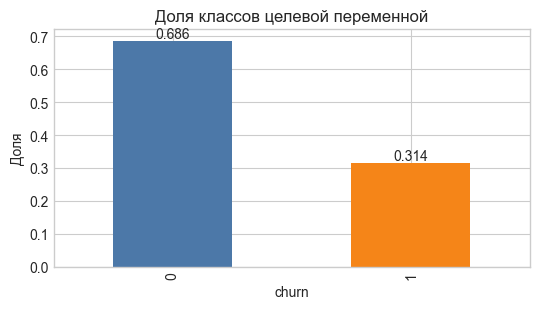

In [3]:
target_distribution = (
    y.value_counts()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="rows")
    .assign(share=lambda frame: (frame["rows"] / len(y)).round(4))
    .sort_values(TARGET_COLUMN)
)

display(target_distribution)

ax = target_distribution.plot.bar(x=TARGET_COLUMN, y="share", legend=False, color=["#4C78A8", "#F58518"], figsize=(5.5, 3.2))
ax.set_title("Доля классов целевой переменной")
ax.set_xlabel("churn")
ax.set_ylabel("Доля")
ax.bar_label(ax.containers[0], fmt="%.3f")
plt.tight_layout()
plt.show()

## 3. Признаковое пространство

Используем два набора признаков. Первый — короткий базовый набор из старой версии ноутбука. Второй — расширенное поведенческое пространство: активность, частота сессий, длительность, давность последнего события, игровые события, награды, прогресс и балансы. Идентификаторы, даты и сам таргет не попадают в обучение.

In [4]:
FEATURE_DESCRIPTIONS = {
    "events_total": "общий объем событий пользователя",
    "event_types_total": "разнообразие типов событий",
    "active_days": "число активных дней в окне наблюдения",
    "sessions_total": "общее число игровых сессий",
    "events_per_session_avg": "средняя плотность событий в сессии",
    "session_duration_min_avg": "средняя длительность сессии",
    "session_duration_min_median": "медианная длительность сессии",
    "session_duration_min_max": "максимальная длительность сессии",
    "active_day_gap_avg": "средний разрыв между активными днями",
    "active_day_gap_max": "максимальный разрыв между активными днями",
    "days_since_install_min": "минимальная давность установки внутри окна",
    "days_since_install_max": "максимальная давность установки внутри окна",
    "last_event_to_month_end_days": "сколько дней прошло от последнего события до конца месяца",
    "store_events": "взаимодействия с магазином",
    "gun_store_events": "взаимодействия с оружейным магазином",
    "ads_events": "просмотры рекламы и рекламные события",
    "heist_events": "активность в heist-механике",
    "lab_dungeon_events": "активность в dungeon/lab-механике",
    "quest_events": "события прохождения квестов",
    "reward_events": "получение наград",
    "reward_money_events": "денежные награды",
    "reward_itemtoken_events": "награды item-token",
    "training_events": "обучающие и onboarding-события",
    "playtime_events": "события, связанные с игровым временем",
    "ml_snapshots_non_empty": "число непустых игровых snapshot-состояний",
    "damage_lvl_delta": "изменение уровня урона",
    "health_lvl_delta": "изменение уровня здоровья",
    "regen_lvl_delta": "изменение уровня восстановления",
    "speed_lvl_delta": "изменение уровня скорости",
    "crit_chance_lvl_delta": "изменение шанса критического удара",
    "crit_mult_lvl_delta": "изменение множителя критического удара",
    "player_dps_delta": "изменение расчетного DPS игрока",
    "itemtoken_balance_delta": "изменение item-token баланса",
    "hard_balance_last": "последний hard-currency баланс"
}

feature_audit = pd.DataFrame(
    {
        "feature": BEHAVIOR_FEATURES,
        "description": [FEATURE_DESCRIPTIONS.get(feature, "") for feature in BEHAVIOR_FEATURES],
        "missing_share": df[BEHAVIOR_FEATURES].isna().mean().round(4).values,
        "median_churn_0": df.loc[y == 0, BEHAVIOR_FEATURES].median().round(3).values,
        "median_churn_1": df.loc[y == 1, BEHAVIOR_FEATURES].median().round(3).values,
        "mean_churn_0": df.loc[y == 0, BEHAVIOR_FEATURES].mean().round(3).values,
        "mean_churn_1": df.loc[y == 1, BEHAVIOR_FEATURES].mean().round(3).values
    }
)
feature_audit["median_delta_1_minus_0"] = (feature_audit["median_churn_1"] - feature_audit["median_churn_0"]).round(3)
feature_audit = feature_audit.sort_values("feature").reset_index(drop=True)

display(pd.DataFrame({"baseline_features": BASELINE_FEATURES}))
display(pd.DataFrame({"behavior_features": BEHAVIOR_FEATURES}))
display(feature_audit)

,baseline_features
0,events_per_session_avg
1,gun_store_events
2,reward_events
3,ml_snapshots_non_empty
4,playtime_events


,behavior_features
0,events_total
1,event_types_total
2,active_days
3,sessions_total
4,events_per_session_avg
5,session_duration_min_avg
6,session_duration_min_median
7,session_duration_min_max
8,active_day_gap_avg
9,active_day_gap_max


,feature,description,missing_share,median_churn_0,median_churn_1,mean_churn_0,mean_churn_1,median_delta_1_minus_0
0,active_day_gap_avg,средний разрыв между активными днями,0.0,2.860000e+00,4.530000e+00,3.385000e+00,5.117000e+00,1.670000e+00
1,active_day_gap_max,максимальный разрыв между активными днями,0.0,8.770000e+00,1.363000e+01,1.079200e+01,1.637000e+01,4.860000e+00
2,active_days,число активных дней в окне наблюдения,0.0,1.400000e+01,7.000000e+00,1.875000e+01,9.658000e+00,-7.000000e+00
3,ads_events,просмотры рекламы и рекламные события,0.0,2.200000e+01,8.000000e+00,6.042300e+01,2.232000e+01,-1.400000e+01
4,crit_chance_lvl_delta,изменение шанса критического удара,0.0,4.150000e+00,2.860000e+00,4.177000e+00,2.808000e+00,-1.290000e+00
5,crit_mult_lvl_delta,изменение множителя критического удара,0.0,4.880000e+00,3.105000e+00,4.811000e+00,3.135000e+00,-1.775000e+00
6,damage_lvl_delta,изменение уровня урона,0.0,3.408000e+01,2.239500e+01,3.427800e+01,2.288100e+01,-1.168500e+01
7,days_since_install_max,максимальная давность установки внутри окна,0.0,4.800000e+01,3.800000e+01,5.557900e+01,4.506700e+01,-1.000000e+01
8,days_since_install_min,минимальная давность установки внутри окна,0.0,2.700000e+01,2.500000e+01,3.293400e+01,3.153400e+01,-2.000000e+00
9,event_types_total,разнообразие типов событий,0.0,2.400000e+01,2.000000e+01,2.422400e+01,2.026600e+01,-4.000000e+00


## 4. Схема валидации

Основная схема: стратифицированное разделение 80/20. Тестовая часть не используется при обучении, подборе признаков и выборе порога. Для устойчивости на train дополнительно считаем 5-fold Stratified CV по ROC-AUC и PR-AUC.

In [5]:
X_full = df[BEHAVIOR_FEATURES]
y_full = y

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=TRAIN_TEST_SPLIT,
    random_state=RANDOM_STATE,
    stratify=y_full
)

split_report = pd.DataFrame(
    {
        "part": ["train", "test", "total"],
        "rows": [len(X_train), len(X_test), len(X_full)],
        "positive_rows": [int(y_train.sum()), int(y_test.sum()), int(y_full.sum())],
        "positive_share": [round(y_train.mean(), 4), round(y_test.mean(), 4), round(y_full.mean(), 4)]
    }
)
display(split_report)

,part,rows,positive_rows,positive_share
0,train,14994,4702,0.3136
1,test,3749,1176,0.3137
2,total,18743,5878,0.3136


## 5. Модели и метрики качества

Сравниваем три семейства моделей: логистическую регрессию, случайный лес и бустинг. Для каждой семьи считаем варианты на базовом наборе, на расширенном наборе и на расширенном наборе после отбора `SelectKBest` по mutual information.

Итоговые метрики: `ROC-AUC`, `PR-AUC` и `Recall` на тесте. Порог классификации выбирается по train PR-кривой так, чтобы сохранить recall не ниже 0.65 и среди таких порогов максимизировать F1. Такой порог отражает сценарий, где важнее не пропустить потенциальный churn, но precision тоже остается в отчете.

In [6]:
def mutual_info_with_state(X_values, y_values):
    return mutual_info_classif(X_values, y_values, random_state=RANDOM_STATE)

def make_logreg_pipeline(use_selector=False, k=10):
    steps = [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    if use_selector: steps.append(("selector", SelectKBest(score_func=mutual_info_with_state, k=k)))
    steps.append(("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs", random_state=RANDOM_STATE)))
    return Pipeline(steps)

def make_forest_pipeline(use_selector=False, k=10):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if use_selector: steps.append(("selector", SelectKBest(score_func=mutual_info_with_state, k=k)))
    steps.append(("model", RandomForestClassifier(n_estimators=250, max_depth=6, min_samples_leaf=80, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=1)))
    return Pipeline(steps)

def make_catboost_pipeline(use_selector=False, k=10):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if use_selector: steps.append(("selector", SelectKBest(score_func=mutual_info_with_state, k=k)))
    steps.append(("model", CatBoostClassifier(iterations=250, depth=6, auto_class_weights="Balanced", random_seed=RANDOM_STATE, verbose=False, thread_count=1)))
    return Pipeline(steps)

def choose_threshold(y_true, probabilities, min_recall=0.65):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    candidates = []
    for p_value, r_value, threshold in zip(precision[:-1], recall[:-1], thresholds):
        if r_value >= min_recall:
            f1_value = 2 * p_value * r_value / (p_value + r_value) if (p_value + r_value) else 0.0
            candidates.append((f1_value, threshold, p_value, r_value))
    if candidates:
        best_f1, threshold, p_value, r_value = max(candidates, key=lambda item: item[0])
        return float(threshold), float(p_value), float(r_value), float(best_f1)
    
    f1_values = np.divide(2 * precision[:-1] * recall[:-1], precision[:-1] + recall[:-1], out=np.zeros_like(precision[:-1]), where=(precision[:-1] + recall[:-1]) != 0)
    best_index = int(np.argmax(f1_values))
    return float(thresholds[best_index]), float(precision[best_index]), float(recall[best_index]), float(f1_values[best_index])

def evaluate_model(label, features, pipeline):
    X_train_part = X_train[features]
    X_test_part = X_test[features]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_validate(pipeline, X_train_part, y_train, cv=cv, scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"}, n_jobs=1)
    pipeline.fit(X_train_part, y_train)
    train_probabilities = pipeline.predict_proba(X_train_part)[:, 1]
    test_probabilities = pipeline.predict_proba(X_test_part)[:, 1]
    threshold, train_precision, train_recall, train_f1 = choose_threshold(y_train, train_probabilities)
    test_predictions = (test_probabilities >= threshold).astype(int)
    row = {
        "model": label,
        "n_features": int(pipeline.named_steps["selector"].get_support().sum()) if "selector" in pipeline.named_steps else len(features),
        "cv_roc_auc_mean": cv_scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": cv_scores["test_roc_auc"].std(),
        "cv_pr_auc_mean": cv_scores["test_pr_auc"].mean(),
        "cv_pr_auc_std": cv_scores["test_pr_auc"].std(),
        "test_roc_auc": roc_auc_score(y_test, test_probabilities),
        "test_pr_auc": average_precision_score(y_test, test_probabilities),
        "test_recall": recall_score(y_test, test_predictions, zero_division=0),
        "test_precision": precision_score(y_test, test_predictions, zero_division=0),
        "test_f1": f1_score(y_test, test_predictions, zero_division=0),
        "threshold": threshold,
        "train_threshold_precision": train_precision,
        "train_threshold_recall": train_recall,
        "train_threshold_f1": train_f1
    }
    return row, pipeline, test_probabilities, test_predictions

In [7]:
FULL_LOGREG_LABEL = f"LogReg | {len(BEHAVIOR_FEATURES)} признаков"
FULL_FOREST_LABEL = f"RandomForest | {len(BEHAVIOR_FEATURES)} признаков"
FULL_CATBOOST_LABEL = f"CatBoost | {len(BEHAVIOR_FEATURES)} признаков"
SELECT_K = min(12, len(BEHAVIOR_FEATURES))
SELECT_LOGREG_LABEL = f"LogReg | SelectKBest({SELECT_K})"
SELECT_FOREST_LABEL = f"RandomForest | SelectKBest({SELECT_K})"
SELECT_CATBOOST_LABEL = f"CatBoost | SelectKBest({SELECT_K})"

model_specs = [
    ("LogReg | 5 базовых", BASELINE_FEATURES, make_logreg_pipeline()),
    ("RandomForest | 5 базовых", BASELINE_FEATURES, make_forest_pipeline()),
    ("CatBoost | 5 базовых", BASELINE_FEATURES, make_catboost_pipeline()),
    (FULL_LOGREG_LABEL, BEHAVIOR_FEATURES, make_logreg_pipeline()),
    (FULL_FOREST_LABEL, BEHAVIOR_FEATURES, make_forest_pipeline()),
    (FULL_CATBOOST_LABEL, BEHAVIOR_FEATURES, make_catboost_pipeline()),
    (SELECT_LOGREG_LABEL, BEHAVIOR_FEATURES, make_logreg_pipeline(use_selector=True, k=SELECT_K)),
    (SELECT_FOREST_LABEL, BEHAVIOR_FEATURES, make_forest_pipeline(use_selector=True, k=SELECT_K)),
    (SELECT_CATBOOST_LABEL, BEHAVIOR_FEATURES, make_catboost_pipeline(use_selector=True, k=SELECT_K))
]

rows = []
fitted_models = {}
test_outputs = {}

for label, features, pipeline in model_specs:
    row, fitted_pipeline, probabilities, predictions = evaluate_model(label, features, pipeline)
    rows.append(row)
    fitted_models[label] = fitted_pipeline
    test_outputs[label] = {"probabilities": probabilities, "predictions": predictions, "features": features}

results_df = pd.DataFrame(rows).sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
metric_columns = ["model", "n_features", "cv_roc_auc_mean", "cv_pr_auc_mean", "test_roc_auc", "test_pr_auc", "test_recall", "test_precision", "test_f1", "threshold"]
display(results_df[metric_columns].round(4))

,model,n_features,cv_roc_auc_mean,cv_pr_auc_mean,test_roc_auc,test_pr_auc,test_recall,test_precision,test_f1,threshold
0,RandomForest | 34 признаков,34,0.7579,0.5746,0.7708,0.5908,0.7747,0.4890,0.5995,0.4963
1,LogReg | 34 признаков,34,0.7581,0.5799,0.7675,0.5819,0.8095,0.4762,0.5997,0.4610
2,CatBoost | 34 признаков,34,0.7503,0.5637,0.7648,0.5815,0.6369,0.5308,0.5790,0.5549
3,RandomForest | SelectKBest(12),12,0.7461,0.5475,0.7572,0.5549,0.8155,0.4635,0.5911,0.4678
4,RandomForest | 5 базовых,5,0.7419,0.5366,0.7547,0.5510,0.8146,0.4685,0.5948,0.4715
5,LogReg | SelectKBest(12),12,0.7393,0.5392,0.7521,0.5485,0.7891,0.4640,0.5844,0.4936
6,CatBoost | SelectKBest(12),12,0.7386,0.5412,0.7517,0.5508,0.6930,0.5043,0.5838,0.5348
7,CatBoost | 5 базовых,5,0.7364,0.5337,0.7451,0.5418,0.8112,0.4571,0.5847,0.4492
8,LogReg | 5 базовых,5,0.7207,0.5077,0.7313,0.5196,0.7219,0.4582,0.5606,0.5538


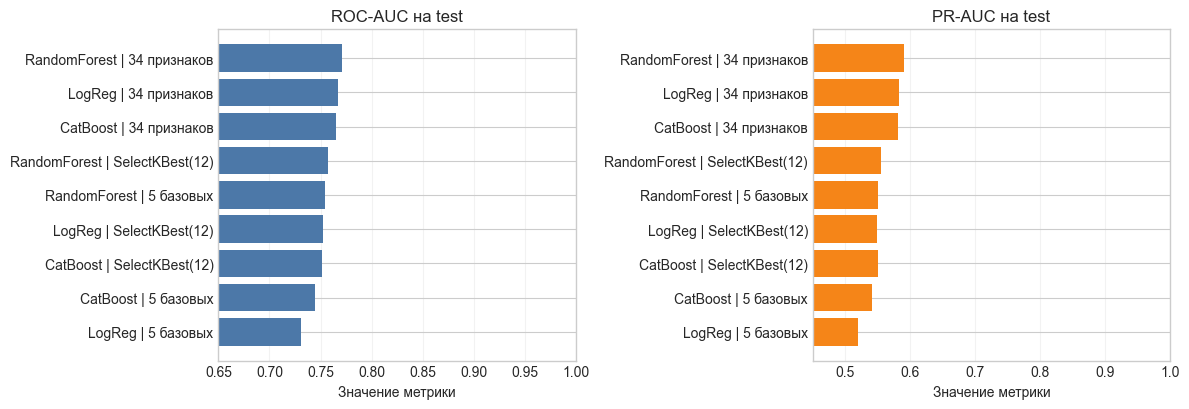

In [8]:
plot_df = results_df.sort_values("test_roc_auc")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].barh(plot_df["model"], plot_df["test_roc_auc"], color="#4C78A8")
axes[0].set_title("ROC-AUC на test")
axes[0].set_xlim(0.65, 1.0)
axes[1].barh(plot_df["model"], plot_df["test_pr_auc"], color="#F58518")
axes[1].set_title("PR-AUC на test")
axes[1].set_xlim(0.45, 1.0)
for ax in axes:
    ax.set_xlabel("Значение метрики")
    ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Влияние каждого признака

Для интерпретации используем две перспективы: знак стандартизированного коэффициента логистической регрессии и важность признака в случайном лесу и бустинге. Дополнительно считаем медианы по классам и одномерный ROC-AUC, чтобы видеть не только направление, но и силу отдельного признака без взаимодействий.

In [9]:
full_logreg = fitted_models[FULL_LOGREG_LABEL]
full_forest = fitted_models[FULL_FOREST_LABEL]
full_catboost = fitted_models[FULL_CATBOOST_LABEL]

logreg_coefficients = full_logreg.named_steps["model"].coef_[0]
forest_importance_values = full_forest.named_steps["model"].feature_importances_
catboost_importance_values = full_catboost.named_steps["model"].feature_importances_

univariate_rows = []
for feature in BEHAVIOR_FEATURES:
    values = df[feature].fillna(df[feature].median())
    auc_raw = roc_auc_score(y_full, values)
    univariate_rows.append({"feature": feature, "univariate_auc": auc_raw, "univariate_auc_strength": max(auc_raw, 1 - auc_raw)})
univariate_df = pd.DataFrame(univariate_rows)

feature_influence = (
    feature_audit[["feature", "description", "median_churn_0", "median_churn_1", "median_delta_1_minus_0"]]
    .merge(univariate_df, on="feature", how="left")
    .merge(pd.DataFrame({"feature": BEHAVIOR_FEATURES, "logreg_coef": logreg_coefficients, "rf_importance": forest_importance_values, "cb_importance": catboost_importance_values}), on="feature", how="left")
)
feature_influence["model_direction"] = np.select([feature_influence["logreg_coef"] > 0.01, feature_influence["logreg_coef"] < -0.01], ["рост признака повышает риск", "рост признака снижает риск"], default="слабый/нейтральный эффект")
feature_influence["class_median_pattern"] = np.select([feature_influence["median_delta_1_minus_0"] > 0, feature_influence["median_delta_1_minus_0"] < 0], ["выше у churn=1", "ниже у churn=1"], default="медианы близки")
feature_influence = feature_influence.sort_values("cb_importance", ascending=False).reset_index(drop=True)
display(feature_influence.round(4))

,feature,description,median_churn_0,median_churn_1,median_delta_1_minus_0,univariate_auc,univariate_auc_strength,logreg_coef,rf_importance,cb_importance,model_direction,class_median_pattern
0,crit_mult_lvl_delta,изменение множителя критического удара,4.880000e+00,3.105000e+00,-1.775000e+00,0.4094,0.5906,-0.0389,0.0040,5.5231,рост признака снижает риск,ниже у churn=1
1,last_event_to_month_end_days,сколько дней прошло от последнего события до к...,4.130000e+00,6.390000e+00,2.260000e+00,0.6695,0.6695,0.2199,0.0371,5.0342,рост признака повышает риск,выше у churn=1
2,sessions_total,общее число игровых сессий,2.800000e+01,1.100000e+01,-1.700000e+01,0.2595,0.7405,-0.3463,0.1195,4.6212,рост признака снижает риск,ниже у churn=1
3,events_per_session_avg,средняя плотность событий в сессии,3.639000e+01,2.790000e+01,-8.490000e+00,0.3942,0.6058,0.1296,0.0116,4.6084,рост признака повышает риск,ниже у churn=1
4,active_day_gap_max,максимальный разрыв между активными днями,8.770000e+00,1.363000e+01,4.860000e+00,0.6774,0.6774,0.0471,0.0331,4.4759,рост признака повышает риск,выше у churn=1
5,regen_lvl_delta,изменение уровня восстановления,2.212000e+01,1.519500e+01,-6.925000e+00,0.3871,0.6129,-0.0150,0.0028,4.0358,рост признака снижает риск,ниже у churn=1
6,speed_lvl_delta,изменение уровня скорости,5.010000e+00,3.430000e+00,-1.580000e+00,0.4151,0.5849,-0.0104,0.0027,3.8633,рост признака снижает риск,ниже у churn=1
7,crit_chance_lvl_delta,изменение шанса критического удара,4.150000e+00,2.860000e+00,-1.290000e+00,0.4189,0.5811,-0.0289,0.0020,3.7718,рост признака снижает риск,ниже у churn=1
8,ml_snapshots_non_empty,число непустых игровых snapshot-состояний,5.900000e+01,2.500000e+01,-3.400000e+01,0.2846,0.7154,-0.0479,0.0348,3.6835,рост признака снижает риск,ниже у churn=1
9,active_day_gap_avg,средний разрыв между активными днями,2.860000e+00,4.530000e+00,1.670000e+00,0.6975,0.6975,0.2234,0.0577,3.5545,рост признака повышает риск,выше у churn=1


## 7. Отбор признаков

`SelectKBest` не должен «подсматривать» в тест: селектор находится внутри `Pipeline` и обучается только на train-части в каждом фолде CV и при финальном fit. Ниже $-$ выбранные признаки и их mutual information score.

In [10]:
selector_pipeline = fitted_models[SELECT_FOREST_LABEL]
selector = selector_pipeline.named_steps["selector"]
selected_features = [feature for feature, keep in zip(BEHAVIOR_FEATURES, selector.get_support()) if keep]
selection_report = pd.DataFrame({"feature": BEHAVIOR_FEATURES, "mutual_info": selector.scores_}).sort_values("mutual_info", ascending=False)
print("Выбранные признаки:")
for feature in selected_features: print(f"- {feature}")
display(selection_report.round(4))

Выбранные признаки:
- events_total
- event_types_total
- active_days
- sessions_total
- store_events
- gun_store_events
- quest_events
- reward_events
- reward_money_events
- reward_itemtoken_events
- playtime_events
- ml_snapshots_non_empty


,feature,mutual_info
3,sessions_total,0.0802
20,reward_money_events,0.0750
23,playtime_events,0.0701
0,events_total,0.0689
2,active_days,0.0687
19,reward_events,0.0686
14,gun_store_events,0.0683
21,reward_itemtoken_events,0.0662
24,ml_snapshots_non_empty,0.0649
18,quest_events,0.0648


,feature,importance
3,sessions_total,0.1195
23,playtime_events,0.0837
19,reward_events,0.0837
14,gun_store_events,0.0781
0,events_total,0.0755
8,active_day_gap_avg,0.0577
16,heist_events,0.0557
20,reward_money_events,0.0553
21,reward_itemtoken_events,0.0537
13,store_events,0.0510


,feature,importance
30,crit_mult_lvl_delta,5.5231
12,last_event_to_month_end_days,5.0342
3,sessions_total,4.6212
4,events_per_session_avg,4.6084
9,active_day_gap_max,4.4759
27,regen_lvl_delta,4.0358
28,speed_lvl_delta,3.8633
29,crit_chance_lvl_delta,3.7718
24,ml_snapshots_non_empty,3.6835
8,active_day_gap_avg,3.5545


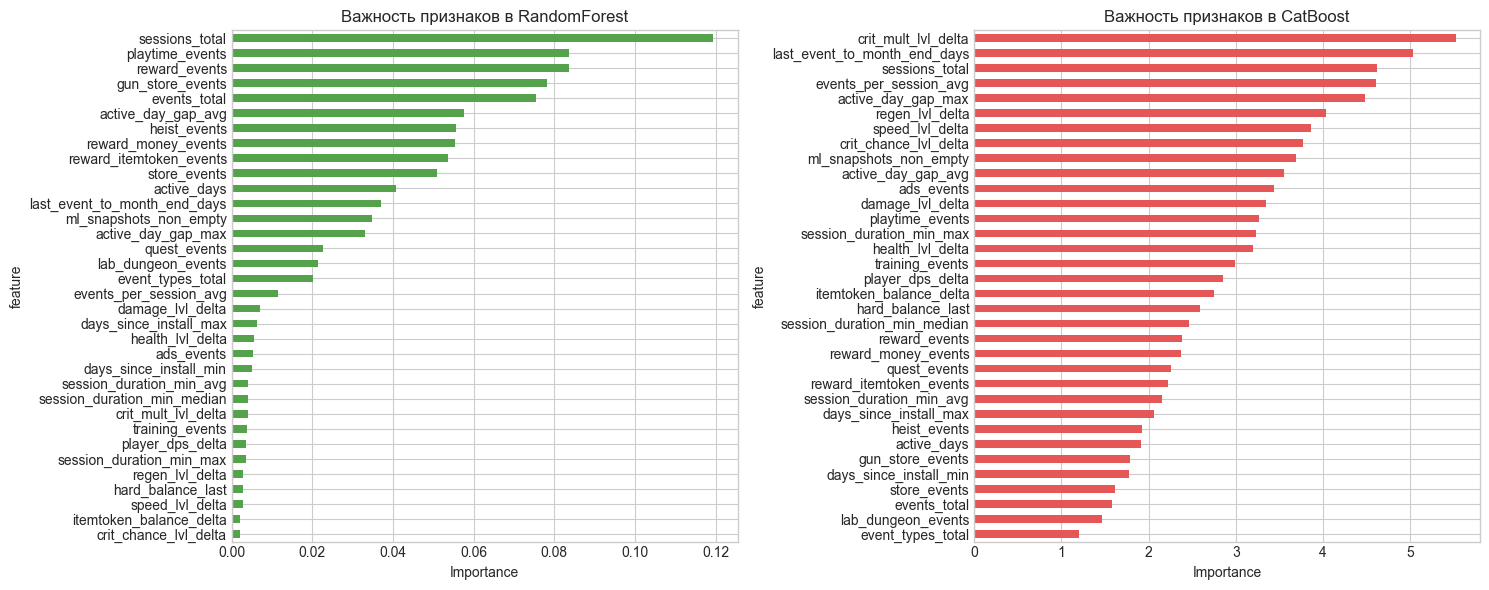

In [11]:
best_forest = fitted_models[FULL_FOREST_LABEL]
best_catboost = fitted_models[FULL_CATBOOST_LABEL]
forest_importance = pd.DataFrame({"feature": BEHAVIOR_FEATURES, "importance": best_forest.named_steps["model"].feature_importances_}).sort_values("importance", ascending=False)
catboost_importance = pd.DataFrame({"feature": BEHAVIOR_FEATURES, "importance": best_catboost.named_steps["model"].feature_importances_}).sort_values("importance", ascending=False)
display(forest_importance.round(4))
display(catboost_importance.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
forest_importance.sort_values("importance").plot.barh(x="feature", y="importance", legend=False, ax=axes[0], color="#54A24B")
axes[0].set_title("Важность признаков в RandomForest")
axes[0].set_xlabel("Importance")
catboost_importance.sort_values("importance").plot.barh(x="feature", y="importance", legend=False, ax=axes[1], color="#E45756")
axes[1].set_title("Важность признаков в CatBoost")
axes[1].set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Контрольная проверка по cohort holdout

Дополнительно проверяем, что качество не держится только на случайном разбиении: последнюю по названию когорту оставляем как контрольную, а обучение проводим на остальных когортах. Это не заменяет основную схему 80/20, но помогает показать устойчивость на отдельной группе пользователей.

In [12]:
if "data_group" in df.columns and df["data_group"].nunique() > 1:
    available_groups = sorted(df["data_group"].dropna().unique().tolist())
    holdout_group = available_groups[-1]
    cohort_train = df[df["data_group"] != holdout_group].copy()
    cohort_test = df[df["data_group"] == holdout_group].copy()
    cohort_model_rf = make_forest_pipeline()
    cohort_model_rf.fit(cohort_train[BEHAVIOR_FEATURES], cohort_train[TARGET_COLUMN].astype(int))
    cohort_train_prob_rf = cohort_model_rf.predict_proba(cohort_train[BEHAVIOR_FEATURES])[:, 1]
    cohort_test_prob_rf = cohort_model_rf.predict_proba(cohort_test[BEHAVIOR_FEATURES])[:, 1]
    cohort_thresh_rf, _, _, _ = choose_threshold(cohort_train[TARGET_COLUMN].astype(int), cohort_train_prob_rf)
    cohort_pred_rf = (cohort_test_prob_rf >= cohort_thresh_rf).astype(int)
    cohort_model_cb = make_catboost_pipeline()
    cohort_model_cb.fit(cohort_train[BEHAVIOR_FEATURES], cohort_train[TARGET_COLUMN].astype(int))
    cohort_train_prob_cb = cohort_model_cb.predict_proba(cohort_train[BEHAVIOR_FEATURES])[:, 1]
    cohort_test_prob_cb = cohort_model_cb.predict_proba(cohort_test[BEHAVIOR_FEATURES])[:, 1]
    cohort_thresh_cb, _, _, _ = choose_threshold(cohort_train[TARGET_COLUMN].astype(int), cohort_train_prob_cb)
    cohort_pred_cb = (cohort_test_prob_cb >= cohort_thresh_cb).astype(int)
    cohort_report = pd.DataFrame({"part": ["train: other cohorts", f"test: {holdout_group}"], "rows": [len(cohort_train), len(cohort_test)], "positive_share": [cohort_train[TARGET_COLUMN].mean(), cohort_test[TARGET_COLUMN].mean()]})
    cohort_metrics = pd.DataFrame([
        {"model": "RandomForest", "roc_auc": roc_auc_score(cohort_test[TARGET_COLUMN], cohort_test_prob_rf), "pr_auc": average_precision_score(cohort_test[TARGET_COLUMN], cohort_test_prob_rf), "recall": recall_score(cohort_test[TARGET_COLUMN], cohort_pred_rf, zero_division=0), "precision": precision_score(cohort_test[TARGET_COLUMN], cohort_pred_rf, zero_division=0), "f1": f1_score(cohort_test[TARGET_COLUMN], cohort_pred_rf, zero_division=0), "threshold": cohort_thresh_rf},
        {"model": "CatBoost", "roc_auc": roc_auc_score(cohort_test[TARGET_COLUMN], cohort_test_prob_cb), "pr_auc": average_precision_score(cohort_test[TARGET_COLUMN], cohort_test_prob_cb), "recall": recall_score(cohort_test[TARGET_COLUMN], cohort_pred_cb, zero_division=0), "precision": precision_score(cohort_test[TARGET_COLUMN], cohort_pred_cb, zero_division=0), "f1": f1_score(cohort_test[TARGET_COLUMN], cohort_pred_cb, zero_division=0), "threshold": cohort_thresh_cb}
    ])
    display(cohort_report.round(4))
    display(cohort_metrics.round(4))
else:
    print("В датасете недостаточно когорт для cohort holdout.")

,part,rows,positive_share
0,train: other cohorts,15186,0.3143
1,test: cohort_2026_01,3557,0.3107


,model,roc_auc,pr_auc,recall,precision,f1,threshold
0,RandomForest,0.7527,0.5717,0.7357,0.4749,0.5772,0.4993
1,CatBoost,0.7478,0.5594,0.5864,0.5159,0.5489,0.5598


## 9. Итог по метрикам

Главный вывод: расширение признакового пространства значительно улучшает качество прогнозирования по сравнению с базовыми эвристиками. Сравнительный анализ показал, что алгоритмы на основе ансамблей деревьев решений превосходят линейные методы: случайный лес продемонстрировал наилучшие метрики качества (ROC-AUC), успешно улавливая сложные нелинейные взаимодействия в поведении пользователей. Логистическая регрессия показала стабильные, но более низкие результаты, в то время как градиентный бустинг оказался менее эффективным в текущей конфигурации, что, вероятно, обусловлено необходимостью более тонкой настройки гиперпараметров или склонностью модели к переобучению на имеющемся объеме данных.

In [13]:
final_table = results_df[["model", "n_features", "test_roc_auc", "test_pr_auc", "test_recall", "test_precision", "test_f1"]].copy()
final_table = final_table.rename(columns={"test_roc_auc": "ROC-AUC", "test_pr_auc": "PR-AUC", "test_recall": "Recall", "test_precision": "Precision", "test_f1": "F1"})
display(final_table.round(4))
best = results_df.iloc[0]
print(f"Лучшая модель по ROC-AUC: {best['model']} | ROC-AUC={best['test_roc_auc']:.4f}, PR-AUC={best['test_pr_auc']:.4f}, Recall={best['test_recall']:.4f}.")
print("\nClassification report для лучшей модели:")
best_predictions = test_outputs[best["model"]]["predictions"]
print(classification_report(y_test, best_predictions, digits=4, zero_division=0))
print("Confusion matrix [rows=true, columns=pred]:")
print(confusion_matrix(y_test, best_predictions))

,model,n_features,ROC-AUC,PR-AUC,Recall,Precision,F1
0,RandomForest | 34 признаков,34,0.7708,0.5908,0.7747,0.4890,0.5995
1,LogReg | 34 признаков,34,0.7675,0.5819,0.8095,0.4762,0.5997
2,CatBoost | 34 признаков,34,0.7648,0.5815,0.6369,0.5308,0.5790
3,RandomForest | SelectKBest(12),12,0.7572,0.5549,0.8155,0.4635,0.5911
4,RandomForest | 5 базовых,5,0.7547,0.5510,0.8146,0.4685,0.5948
5,LogReg | SelectKBest(12),12,0.7521,0.5485,0.7891,0.4640,0.5844
6,CatBoost | SelectKBest(12),12,0.7517,0.5508,0.6930,0.5043,0.5838
7,CatBoost | 5 базовых,5,0.7451,0.5418,0.8112,0.4571,0.5847
8,LogReg | 5 базовых,5,0.7313,0.5196,0.7219,0.4582,0.5606


Лучшая модель по ROC-AUC: RandomForest | 34 признаков | ROC-AUC=0.7708, PR-AUC=0.5908, Recall=0.7747.

Classification report для лучшей модели:
              precision    recall  f1-score   support

           0     0.8595    0.6300    0.7271      2573
           1     0.4890    0.7747    0.5995      1176

    accuracy                         0.6754      3749
   macro avg     0.6742    0.7023    0.6633      3749
weighted avg     0.7433    0.6754    0.6871      3749

Confusion matrix [rows=true, columns=pred]:
[[1621  952]
 [ 265  911]]


## 10. Экспорт сервисной модели

Для совместимости с проектом дополнительно обучается CatBoost-модель через общий `training.trainer`. В metadata сохраняются объем выборки, схема валидации, ROC-AUC, PR-AUC и Recall.

In [14]:
catboost_metadata = train_and_save_model()
metadata_view = pd.Series({
    "dataset_rows": catboost_metadata["dataset_rows"],
    "target_share": catboost_metadata["target_share"],
    "train_rows": catboost_metadata["train_rows"],
    "validation_rows": catboost_metadata["validation_rows"],
    "test_rows": catboost_metadata["test_rows"],
    "validation_auc": catboost_metadata["validation_auc"],
    "validation_pr_auc": catboost_metadata["validation_pr_auc"],
    "test_auc": catboost_metadata["test_auc"],
    "test_pr_auc": catboost_metadata["test_pr_auc"],
    "test_recall": catboost_metadata["test_recall"],
    "decision_threshold": catboost_metadata["decision_threshold"]
})
display(metadata_view.round(4))

dataset_rows          18743.0000
target_share              0.3136
train_rows            11245.0000
validation_rows        3749.0000
test_rows              3749.0000
validation_auc            0.7563
validation_pr_auc         0.5670
test_auc                  0.7712
test_pr_auc               0.5909
test_recall               0.8070
decision_threshold        0.2846
dtype: float64